## EDA on locations in Hägersten-Älvsjö - using pandas

In [2]:
import pandas as pd

df = pd.read_csv(r'..\data_files\complete_alvsjo_data.csv')

df.head()

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon,Stadsdel,stadsdelsomrade
0,Marino,restaurant,Restaurang & Snabbmat,Klubbacken,51,59.305325,17.963290,Hägersten,Hägersten-Älvsjö
1,Hemköp Stockholm Älvsjö,supermarket,Matbutik,Sjättenovembervägen,208,59.278752,18.002280,Liseberg,Hägersten-Älvsjö
2,OKQ8,fuel,Bensinmack,Kontrollvägen,NaN,59.294435,18.002588,Västberga,Hägersten-Älvsjö
3,Circle K,fuel,Bensinmack,Nioörtsvägen,NaN,59.299954,18.012147,Västberga,Hägersten-Älvsjö
4,McDonald's,fast_food,Restaurang & Snabbmat,Lerkrogsvägen,NaN,59.293074,18.001211,Västberga,Hägersten-Älvsjö


In [3]:
df.shape

(545, 9)

In [4]:
df.nunique()

Namn               344
Typ                 17
Kategori            14
Gata               210
Nr                  69
Lat                545
Lon                545
Stadsdel            15
stadsdelsomrade      1
dtype: int64

In [5]:
df['Kategori'].value_counts().head()

Kategori
Restaurang & Snabbmat    192
Lekplats                 186
Kafé                      40
Gym/Utomhusgym            36
Matbutik                  26
Name: count, dtype: int64

In [6]:
df['Typ'].value_counts().head()

Typ
playground     186
restaurant     138
fast_food       54
cafe            40
supermarket     26
Name: count, dtype: int64

In [7]:
df['Stadsdel'].value_counts().head()

Stadsdel
Liljeholmen         93
Fruängen            68
Midsommarkransen    64
Älvsjö              57
Aspudden            50
Name: count, dtype: int64

In [8]:
import duckdb

df_query = duckdb.query("""--sql
                        SELECT DISTINCT Kategori
                        FROM df
                        WHERE Typ IN ('restaurant', 'fast_food')""").to_df()

df_query

,Kategori
0,Restaurang & Snabbmat


In [9]:
df_cleaned = duckdb.query("""--sql
                        SELECT *,
                          CASE
                            WHEN Typ IN ('restaurant', 'fast_food') THEN 'Restaurant or Fast Food'
                            ELSE Typ
                          END AS type_cleaned
                        FROM df""").to_df()

df_cleaned = df_cleaned.drop(columns=['Typ'])
df_cleaned.head()

,Namn,Kategori,Gata,Nr,Lat,Lon,Stadsdel,stadsdelsomrade,type_cleaned
0,Marino,Restaurang & Snabbmat,Klubbacken,51,59.305325,17.963290,Hägersten,Hägersten-Älvsjö,Restaurant or Fast Food
1,Hemköp Stockholm Älvsjö,Matbutik,Sjättenovembervägen,208,59.278752,18.002280,Liseberg,Hägersten-Älvsjö,supermarket
2,OKQ8,Bensinmack,Kontrollvägen,None,59.294435,18.002588,Västberga,Hägersten-Älvsjö,fuel
3,Circle K,Bensinmack,Nioörtsvägen,None,59.299954,18.012147,Västberga,Hägersten-Älvsjö,fuel
4,McDonald's,Restaurang & Snabbmat,Lerkrogsvägen,None,59.293074,18.001211,Västberga,Hägersten-Älvsjö,Restaurant or Fast Food


In [10]:
df_cleaned['type_cleaned'].value_counts().head()

type_cleaned
Restaurant or Fast Food    192
playground                 186
cafe                        40
supermarket                 26
fitness_centre              24
Name: count, dtype: int64

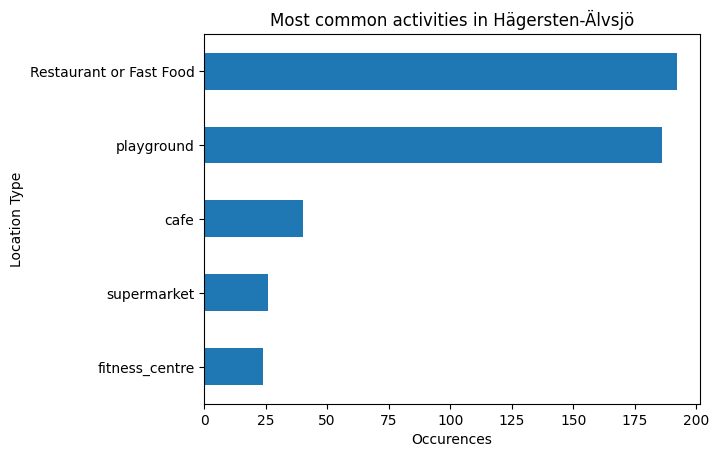

In [23]:
import matplotlib.pyplot as plt

ax = (
    df_cleaned['type_cleaned']
    .value_counts()
    .head(5)
    .plot(
        kind='barh',
        title='Most common activities in Hägersten-Älvsjö',
        ylabel='Location Type',
        xlabel='Occurences'
    )
)

ax.invert_yaxis()

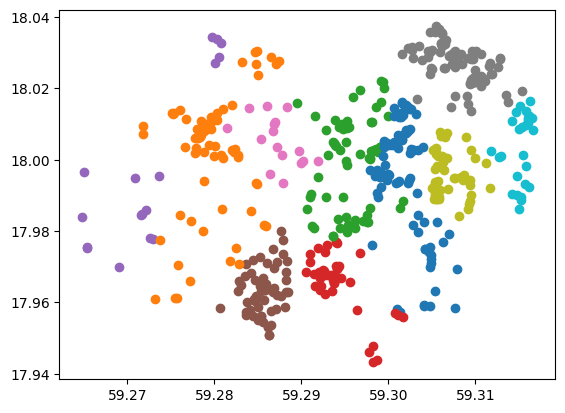

In [22]:
stadsdelar = df_cleaned['Stadsdel'].unique()
for område in stadsdelar:
    subset = df_cleaned[df_cleaned['Stadsdel'] == område]
    plt.scatter(subset['Lat'], subset['Lon'], label=område)

plt.show()